In [1]:
from ultralytics import YOLO
import os

In [3]:

print("Train Images:", len(os.listdir("../data/helmet_dataset/images/train")))
print("Val Images:", len(os.listdir("../data/helmet_dataset/images/valid")))

Train Images: 800
Val Images: 142


In [4]:
model = YOLO("yolov8n.pt")

In [6]:

img_dir = "../data/helmet_dataset/images/train"
lbl_dir = "../data/helmet_dataset/labels/train"

missing = []

for img in os.listdir(img_dir):
    name = os.path.splitext(img)[0] + ".txt"
    if not os.path.exists(os.path.join(lbl_dir, name)):
        missing.append(img)

print("Images without labels:", len(missing))

Images without labels: 0


In [8]:
results = model.train(
    data="../data/helmet_dataset/helmet_data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="../runs",
    name="helmet_detector"
)

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/helmet_dataset/helmet_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_detector3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [9]:
print(os.listdir("runs/runs"))

['helmet_detector3']


In [10]:
print(os.listdir("runs/runs/helmet_detector3/weights"))

['last.pt', 'best.pt']


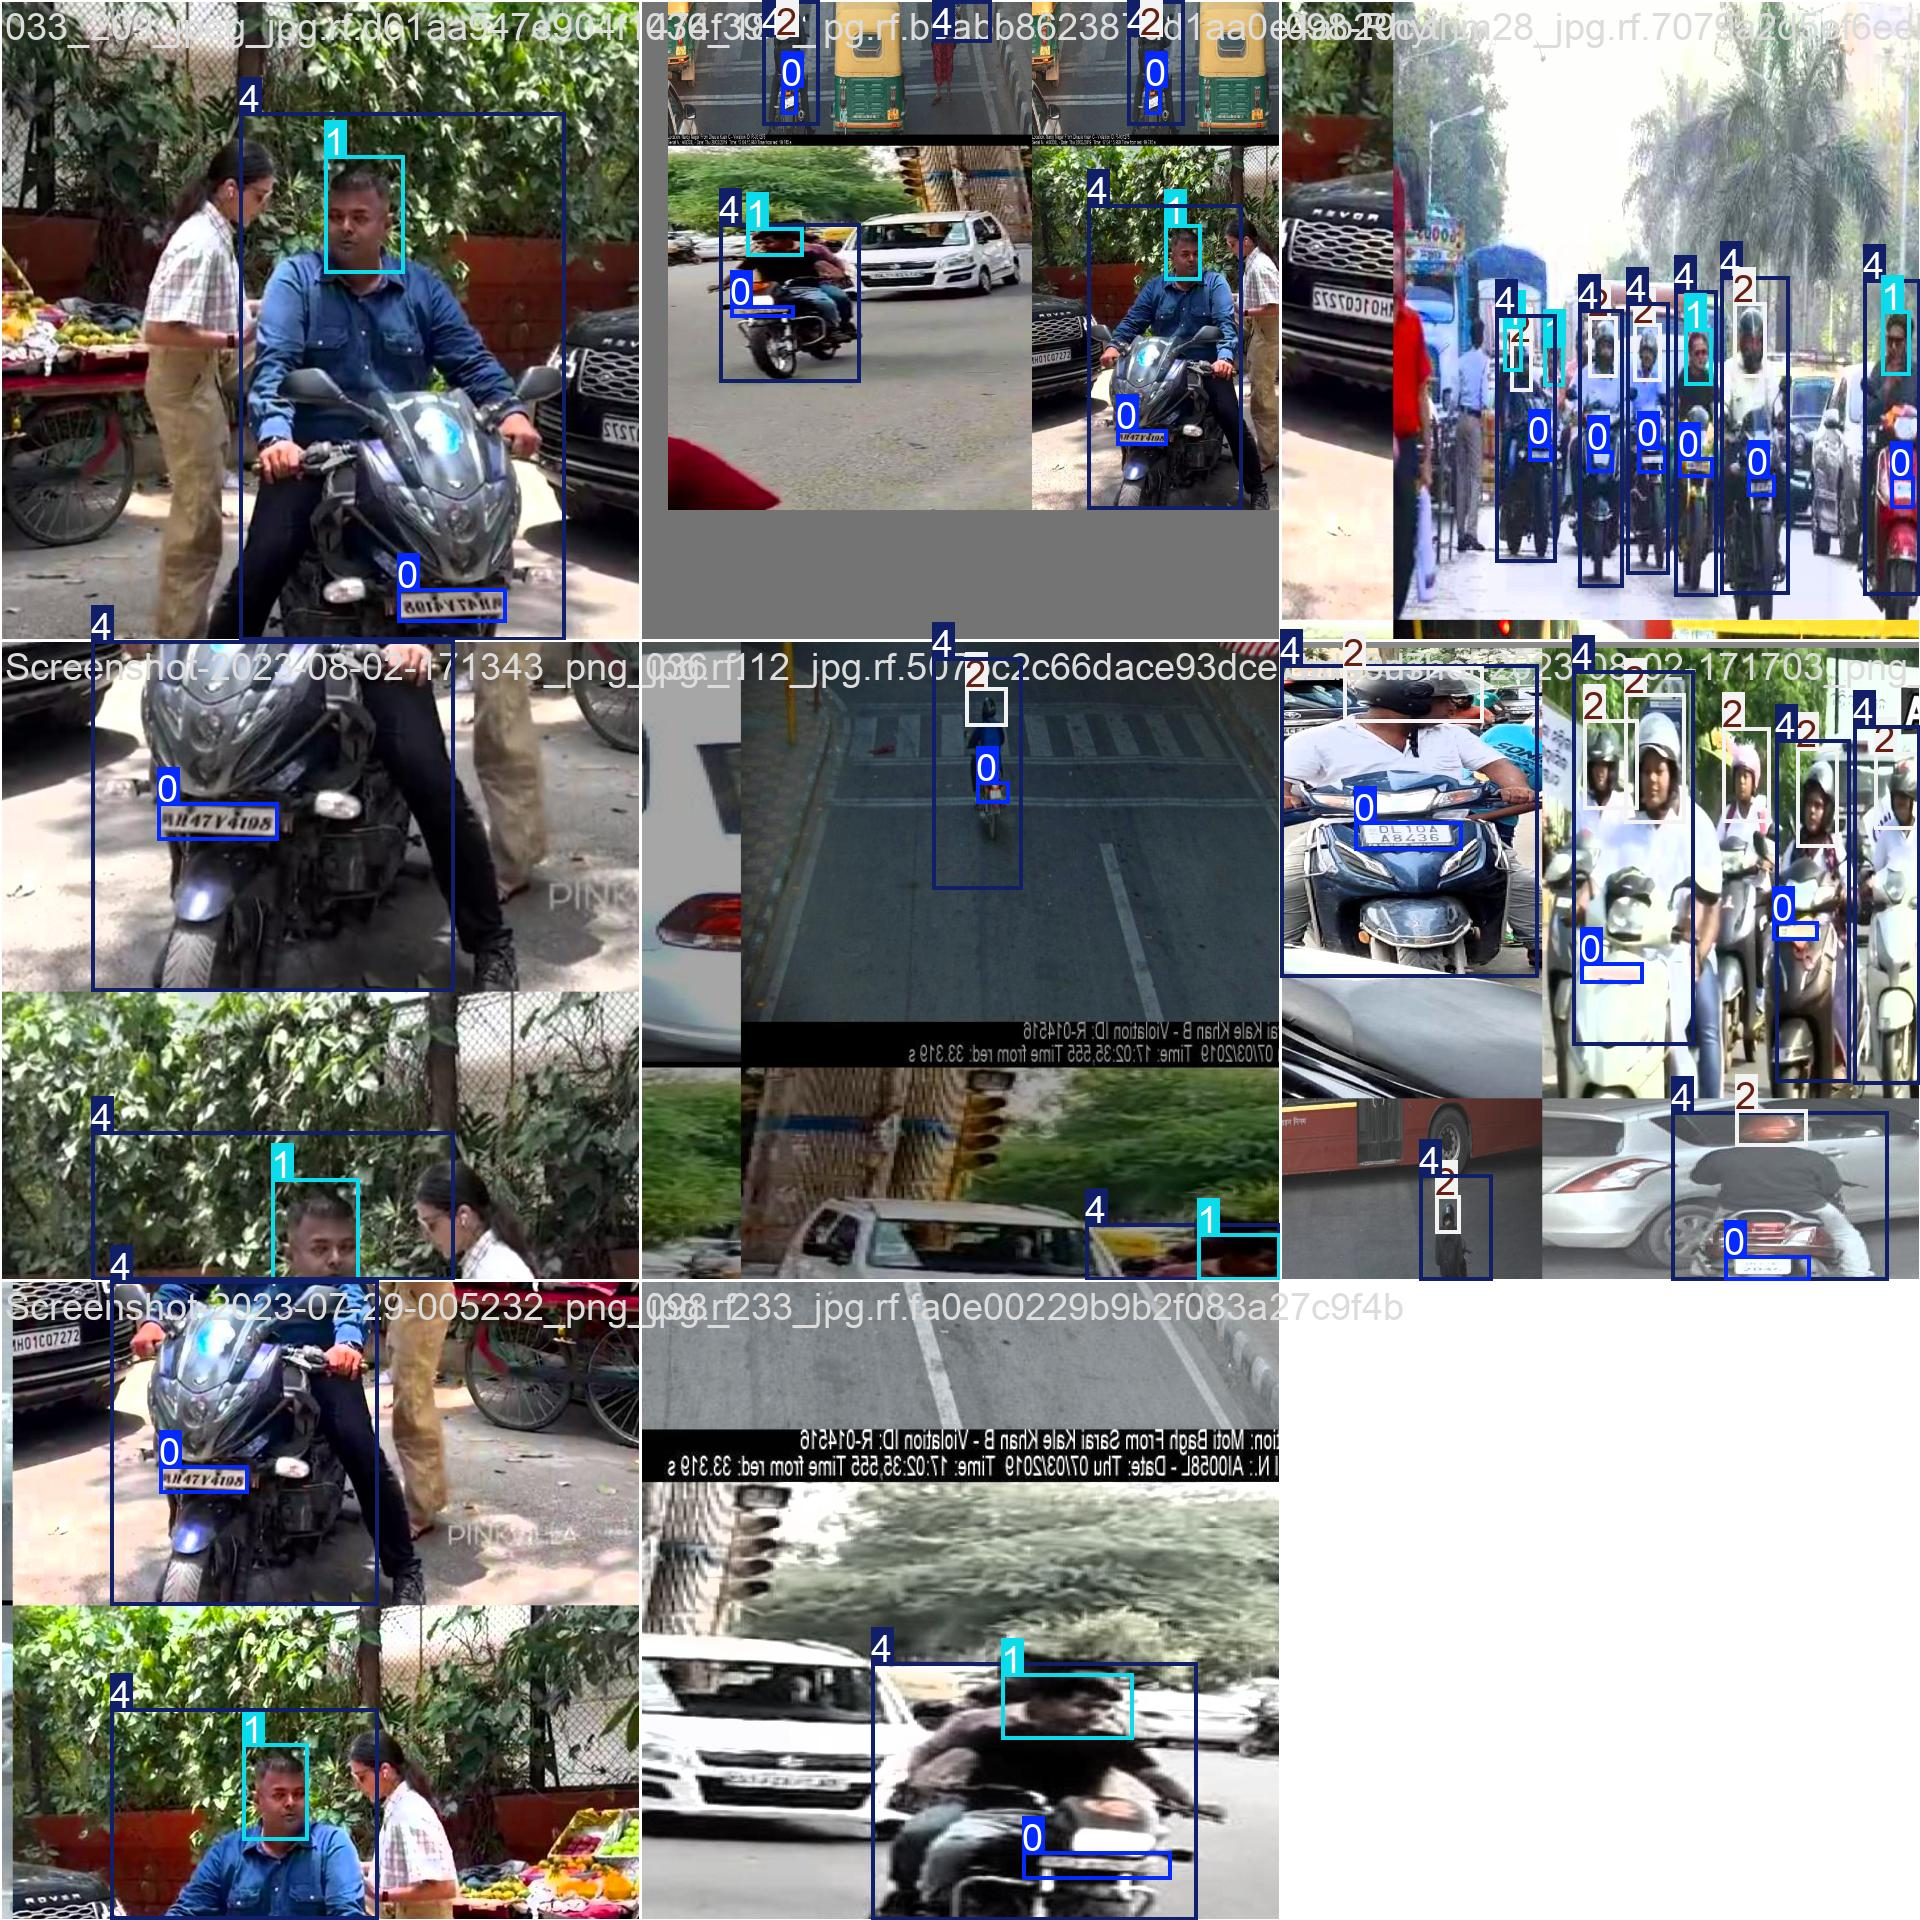

In [11]:
from IPython.display import Image

Image("runs/runs/helmet_detector3/train_batch0.jpg")

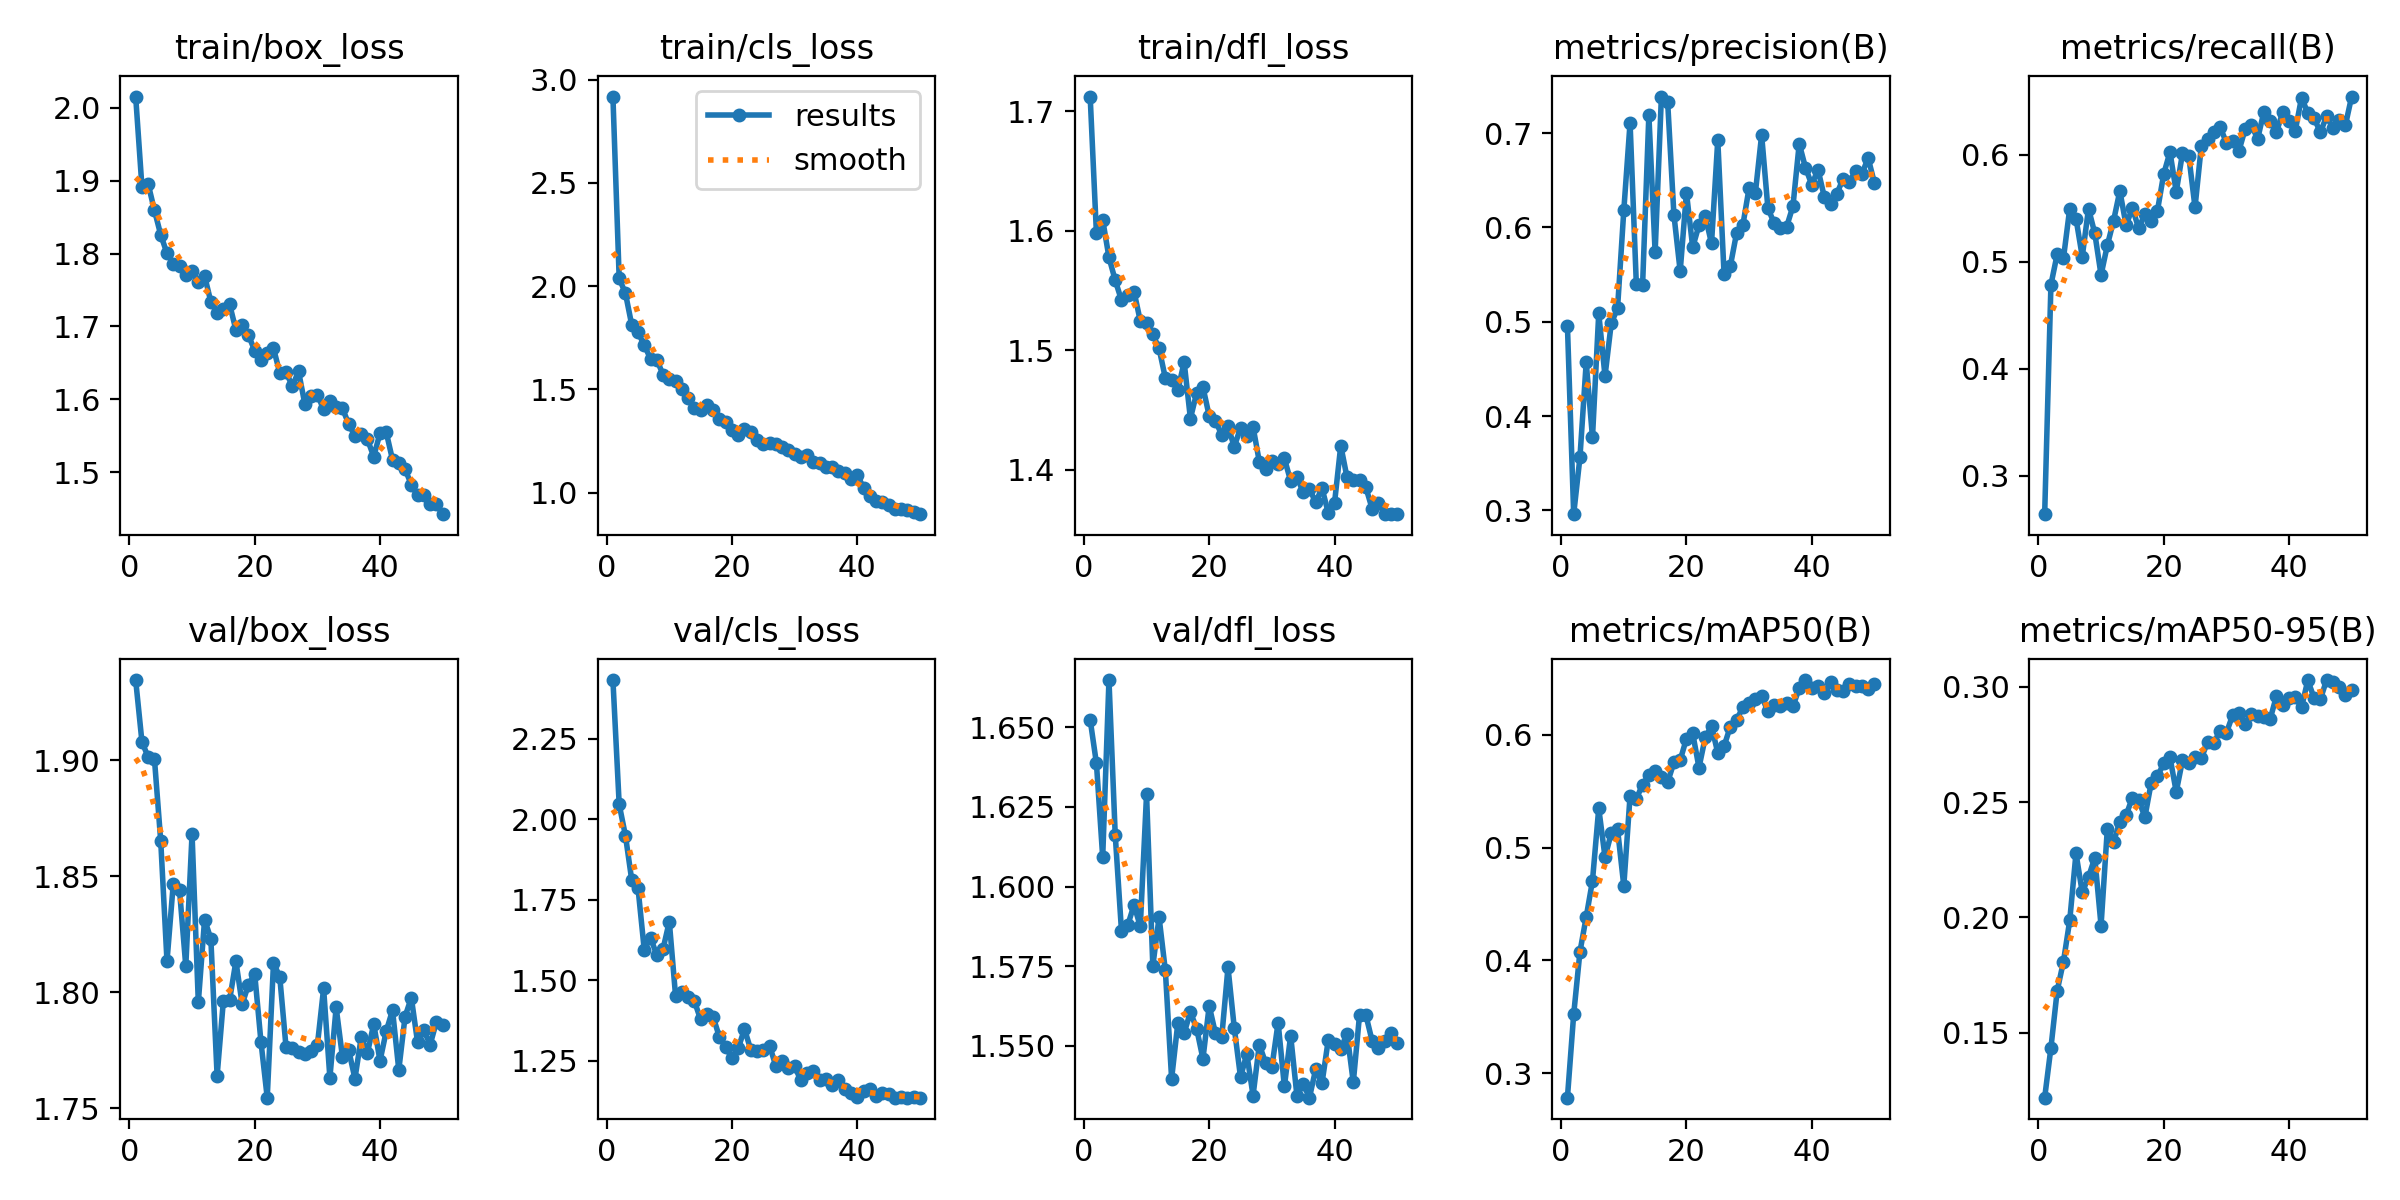

In [13]:

Image("runs/runs/helmet_detector3/results.png")

In [14]:
metrics = model.val()

print("Precision:", metrics.box.p)
print("Recall:", metrics.box.r)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1975.2±1148.5 MB/s, size: 71.8 KB)
val: Scanning /home/lurvik/Traffic_Anamoly_Detection/data/helmet_dataset/labels/val.cache... 142 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 142/142 59.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.6s/it 14.8s1.7s
                   all        142       1064      0.647      0.636      0.645      0.303
                 plate        117        258      0.781      0.671      0.706      0.256
             no_helmet         59        179      0.703      0.598      0.638      0.252
           good_helmet        114        274       0.66      0.818       0.77      0.368
            bad_helmet         28         53      0.314      0.189      0.225 

In [16]:
import shutil

source = "../notebooks/runs/runs/helmet_detector3/weights/best.pt"
destination = "../models/helmet_detector.pt"

os.makedirs("../models", exist_ok=True)

shutil.copy(source, destination)

print("Helmet model saved to models folder")

Helmet model saved to models folder


In [17]:
model_test = YOLO("../models/helmet_detector.pt")

model_test.predict(
    source="../data/videos/traffic_video.mp4",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 384x640 1 good_helmet, 1 bad_helmet, 2 riders, 111.1ms
video 1/1 (frame 2/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 384x640 1 bad_helmet, 2 riders, 89.3ms
video 1/1 (frame 3/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 384x640 1 good_helmet, 1 bad_helmet, 3 ride

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'plate', 1: 'no_helmet', 2: 'good_helmet', 3: 'bad_helmet', 4: 'rider'}
 obb: None
 orig_img: array([[[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        [[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        [[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        ...,
 
        [[114, 111, 112],
         [114, 111, 112],
         [114, 111, 112],
         ...,
         [106, 103, 104],
         [106, 103, 104],
         [106, 103, 104]],
 
        [[113, 110, 111],
         [113, 110, 11

In [18]:
import cv2

input_video = "runs/detect/predict2/traffic_video.avi"
output_video = "runs/detect/predict2/output.mp4"

cap = cv2.VideoCapture(input_video)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)

cap.release()
out.release()

print("Conversion completed")

Conversion completed
